In [6]:
# Librerias necesarias
import os
import sys
import json
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from kpis import * 

# Open a CSV file
file_path = 'resultados simulacion/ModeloProactivo_T4500_C4208/logs/1.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)

def calcular_kpis_por_intervalos_separados(df, step=50 * 12, T_max=4200 * 12, **kwargs):
    def flatten_dict(d, parent_key='', sep='_'):
        """Aplana un diccionario anidado."""
        items = []
        for k, v in d.items():
            new_key = f"{parent_key}{sep}{k}" if parent_key else k
            if isinstance(v, dict):
                items.extend(flatten_dict(v, new_key, sep=sep).items())
            else:
                items.append((new_key, v))
        return dict(items)

    registros = {
        "LOS_hospitalizado": [],
        "LOS_lista_espera": [],
        "costo_diario_promedio": [],
        "costo_promedio_paciente": [],
        "tasa_entrada_vs_salida": []
    }

    for start_time in range(0, T_max, step):
        end_time = start_time + step
        kpis = calcular_kpis(df, start_time=start_time, end_time=end_time, **kwargs)

        for kpi_nombre in registros:
            fila = {"ciclo_inicio": start_time, "ciclo_fin": end_time}
            valor = kpis[kpi_nombre]

            if isinstance(valor, dict):
                fila.update(flatten_dict(valor, parent_key=kpi_nombre))
            else:
                fila[kpi_nombre] = valor

            registros[kpi_nombre].append(fila)

    df_los_hosp = pd.DataFrame(registros["LOS_hospitalizado"])
    df_los_le = pd.DataFrame(registros["LOS_lista_espera"])
    df_costos_dia = pd.DataFrame(registros["costo_diario_promedio"])
    df_costos_pac = pd.DataFrame(registros["costo_promedio_paciente"])
    df_tasas = pd.DataFrame(registros["tasa_entrada_vs_salida"])

    return df_los_hosp, df_los_le, df_costos_dia, df_costos_pac, df_tasas

def graficar_df_en_grid(df, columnas_y=None, columna_x="ciclo_inicio", columna_fin="ciclo_fin",
                         paso_xticks=10000, marker_size=0, n_cols=2, ancho_base=6, alto_base=3):
    """
    Grafica varias columnas de un DataFrame en una grilla, ajustando tamaño automáticamente.
    Muestra eje X en cada subplot, compatible con 1 solo gráfico o muchos.
    """
    # Eje X: centro del intervalo en horas
    if columna_x in df.columns and columna_fin in df.columns:
        eje_x = ((df[columna_x] + df[columna_fin]) / 2)
    else:
        eje_x = df[columna_x] if columna_x in df.columns else range(len(df))

    # Columnas a graficar
    if columnas_y is None:
        columnas_y = [col for col in df.columns if col not in [columna_x, columna_fin]]

    n_plots = len(columnas_y)
    n_rows = math.ceil(n_plots / n_cols)
    figsize = (n_cols * ancho_base, n_rows * alto_base)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # Forzar axes a una lista unidimensional
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for i, col in enumerate(columnas_y):
        ax = axes[i]
        ax.plot(eje_x, df[col], marker='o', markersize=marker_size)
        ax.set_title(col, fontsize=10)
        #ax.set_ylabel(col)
        ax.set_xlabel("Horas simuladas")
        ax.grid(True)

        # xticks personalizados
        min_x, max_x = eje_x.min(), eje_x.max()
        xticks = np.arange((min_x // paso_xticks) * paso_xticks,
                           ((max_x // paso_xticks) + 2) * paso_xticks,
                           paso_xticks)
        ax.set_xticks(xticks)

    # Eliminar subplots vacíos si hay más espacios que gráficos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("KPIs por intervalo de tiempo", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [7]:
df1, df2, df3, df4, df5 = calcular_kpis_por_intervalos_separados(df, step=50 * 12, T_max=4200 * 12, detallado=False)

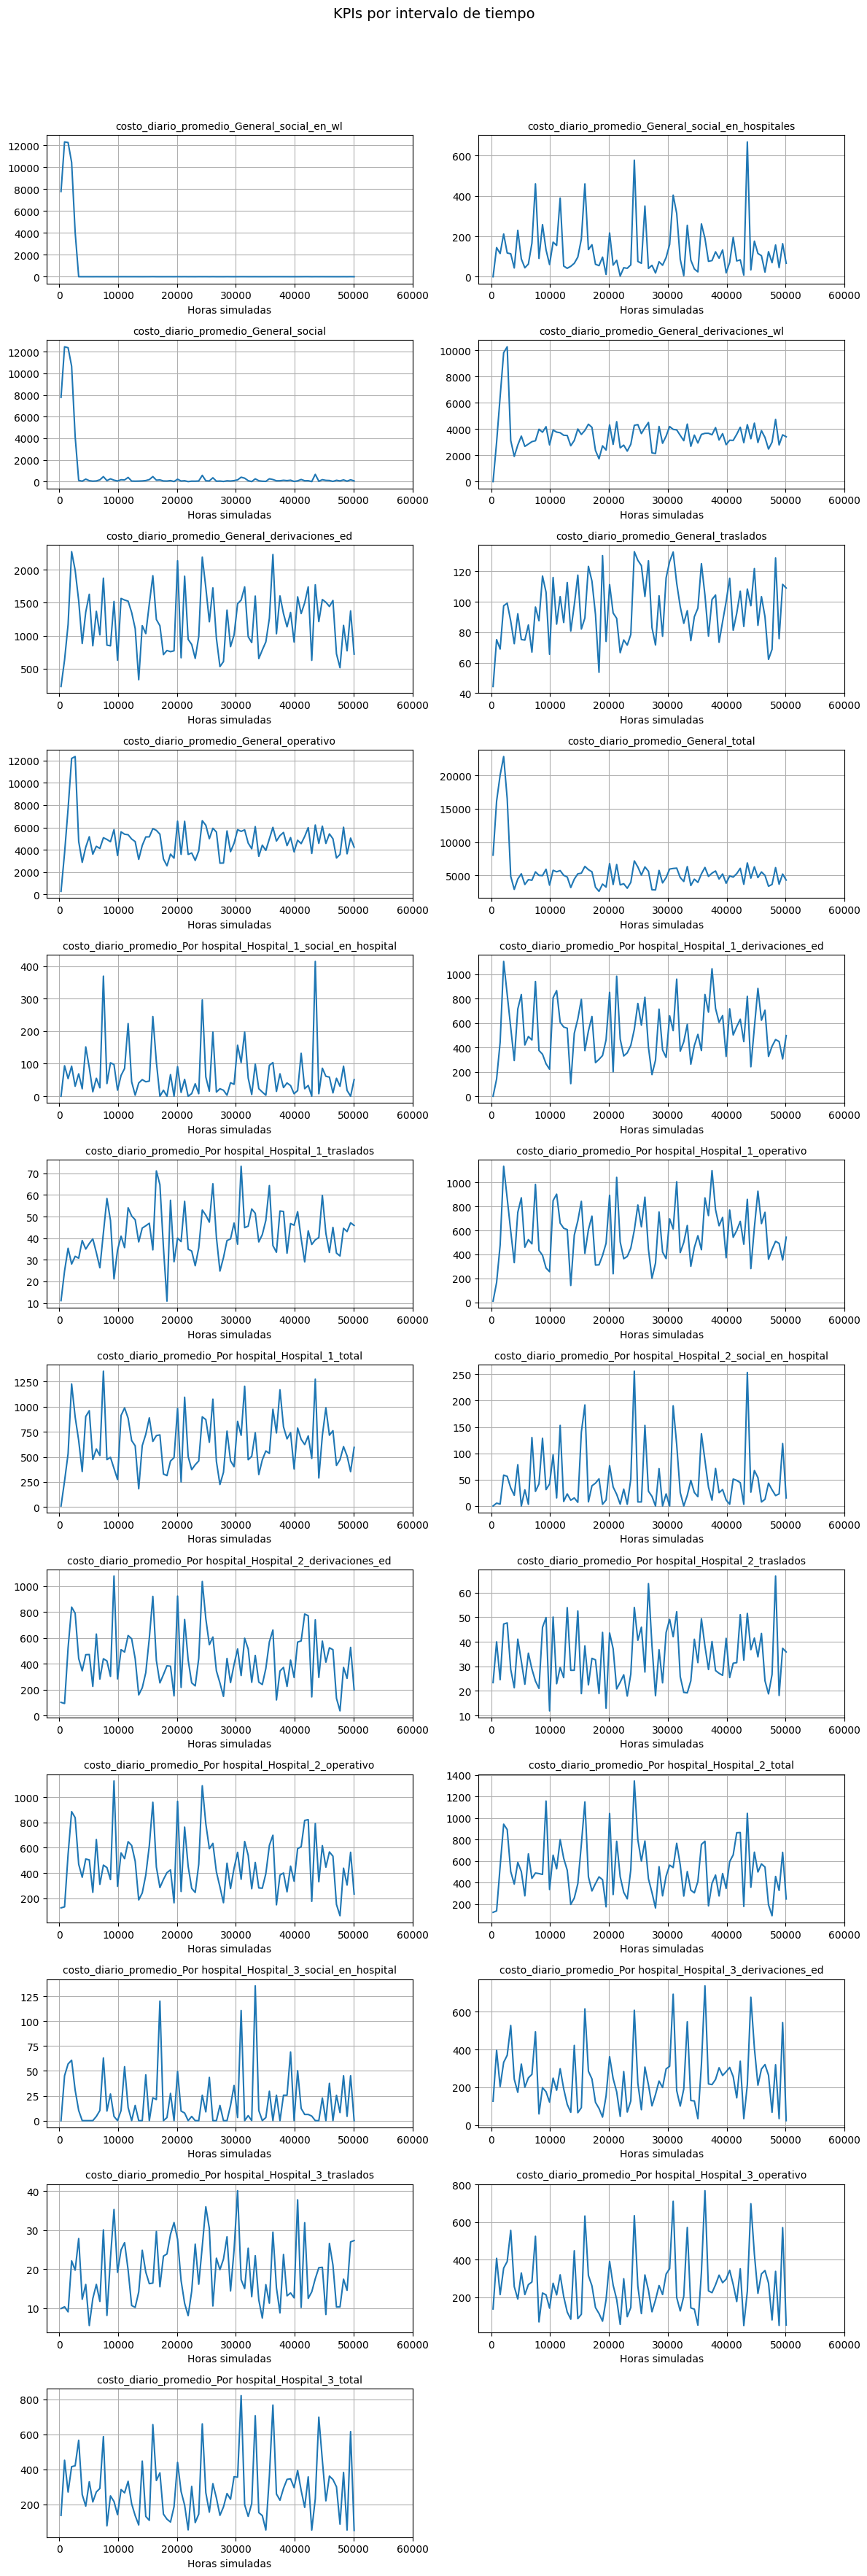

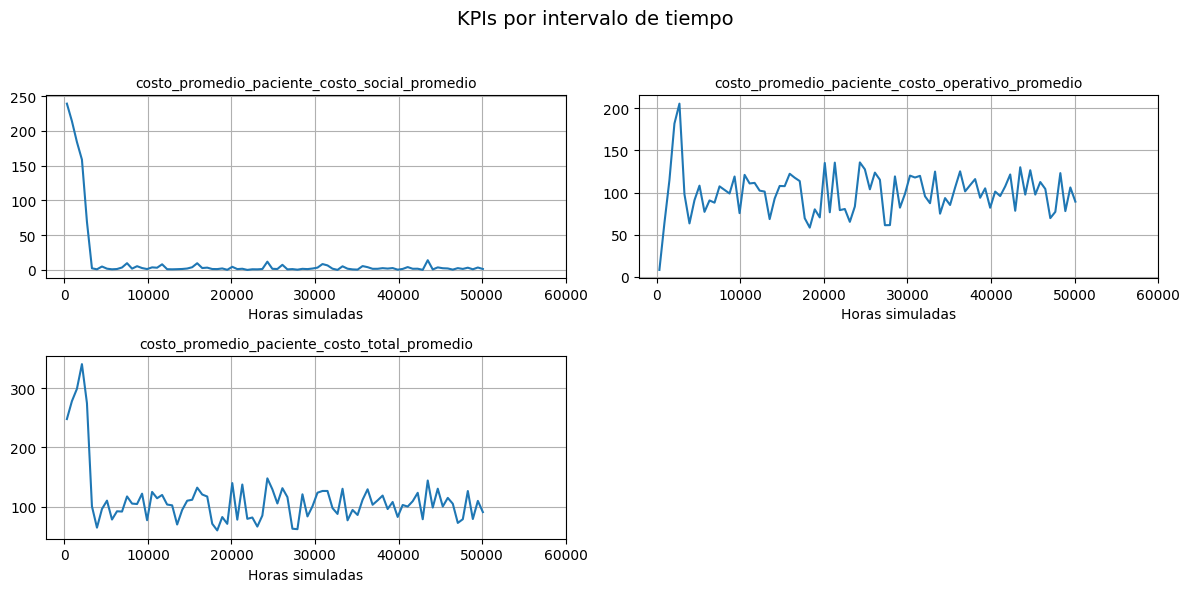

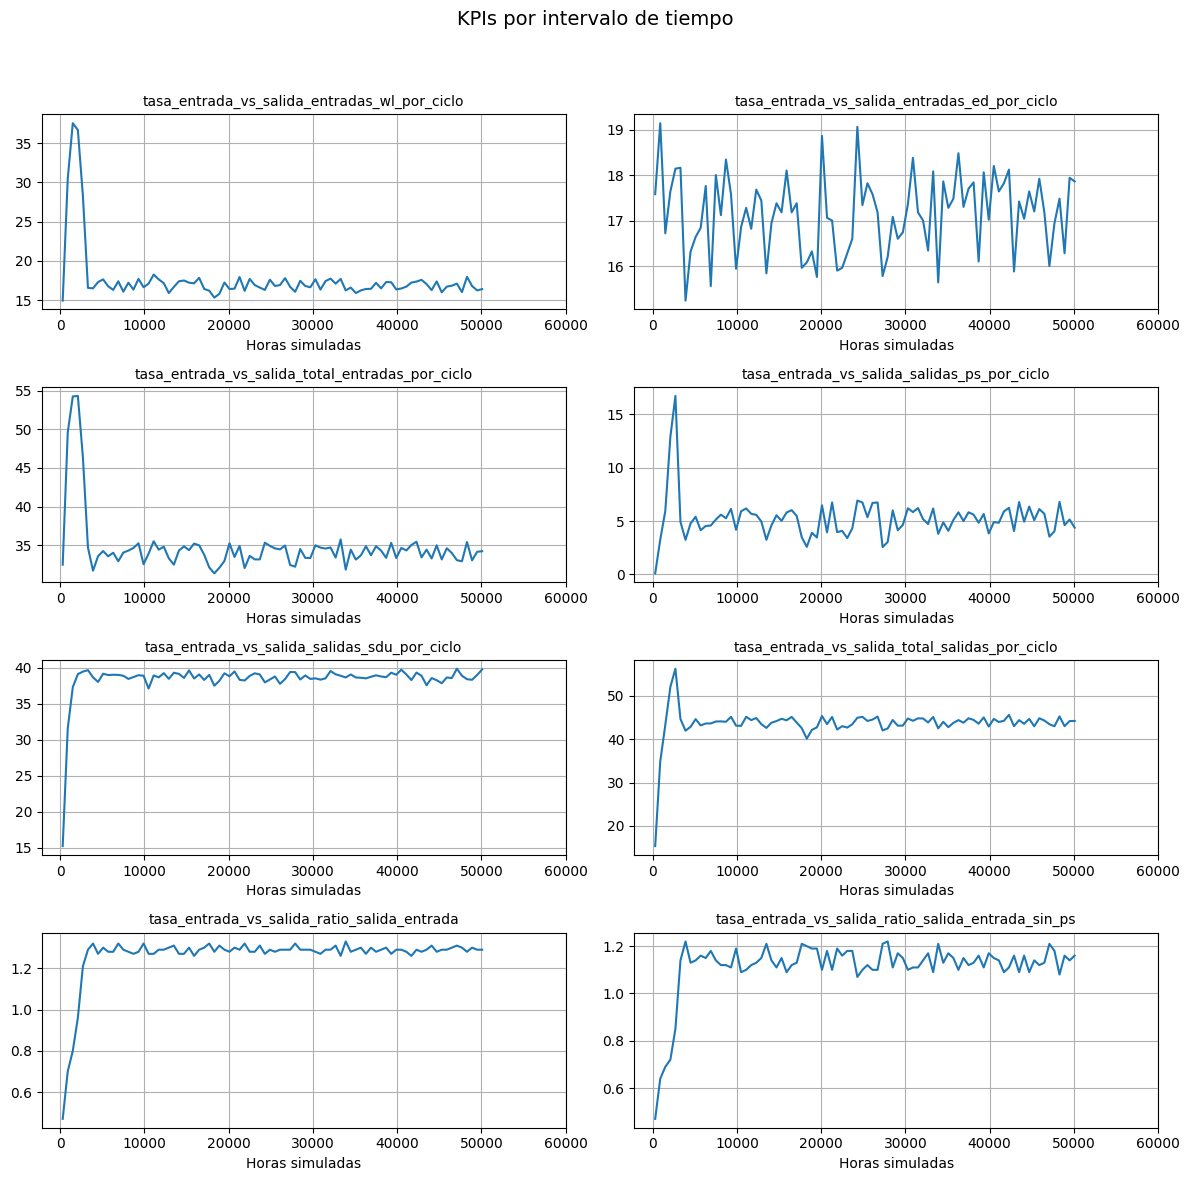

In [8]:
# graficar_df_en_grid(df1)
# graficar_df_en_grid(df2)
graficar_df_en_grid(df3)
graficar_df_en_grid(df4)
graficar_df_en_grid(df5)